## `Neuropixels1ExtracellularLocations`

A Neuropixels 1.0 staggered layout (two sites per row, four columns). We use 96 sites here so the
probe is a comparable scale to the circuit (the default is 384 sites, i.e. a ~3.8 mm shank). Like
the linear array, it is inserted along the soma cloud's principal axis (as a probe would go down
the cortical depth), so it threads through the neurons rather than sitting across them. Every
electrode must map to a distinct position.

In [1]:
from pathlib import Path

import bluepysnap as snap
import matplotlib.pyplot as plt
import numpy as np

import obi_one as obi

## Load the circuit and its soma positions

By default this uses the bundled tiny circuit; set `USE_STAGING_CIRCUIT = True` below to stage a circuit from staging by ID instead.

In [2]:
# Optionally stage a circuit from staging by ID (as create_recording_array.py does) instead of the
# bundled tiny circuit. Set USE_STAGING_CIRCUIT = True (requires obi_auth + staging access); the
# resolved circuit's somas then drive both the visualisation and the electrode placement below.
USE_STAGING_CIRCUIT = True
# STAGING_CIRCUIT_ID = "ecc2e394-db99-4203-b162-608c0ef12cb9" # 10 neuron microcircuit
STAGING_CIRCUIT_ID = "1c81aa3e-7e9d-437a-91c8-aa5f7bc3bd02" # hex0


def load_staging_sonata_circuit() -> snap.Circuit:
    """Return the staging circuit's snap.Circuit, staging it into obi-output on first use.

    If the circuit is already staged locally under obi-output it is loaded straight from disk,
    without contacting staging (no token or download needed).
    """
    # Local obi-output cache location (outside the repo), as in create_recording_array.py.
    repo_root = next(
        base
        for base in [Path.cwd(), *Path.cwd().parents]
        if (base / "pyproject.toml").exists() and (base / "examples").exists()
    )
    obi_output_dir = repo_root.parent.parent / "obi-output"
    staged_config = (
        obi_output_dir
        / "entity_cache"
        / "sonata_circuit"
        / STAGING_CIRCUIT_ID
        / "circuit_config.json"
    )

    # Reuse the already-staged circuit if present; otherwise stage it from staging.
    if staged_config.exists():
        print(f"Using circuit already staged at {staged_config.parent}")
        return snap.Circuit(str(staged_config))

    from entitysdk import Client, ProjectContext
    from obi_auth import get_token

    from obi_one.utils import db_sdk

    db_client = Client(
        api_url="https://staging.openbraininstitute.org/api/entitycore",
        project_context=ProjectContext(
            virtual_lab_id=obi.LAB_ID_STAGING_TEST, project_id=obi.PROJECT_ID_STAGING_TEST
        ),
        token_manager=get_token(environment="staging"),
    )
    resolved_circuit, _ = db_sdk.resolve_circuit(
        obi.CircuitFromID(id_str=STAGING_CIRCUIT_ID),
        db_client=db_client,
        entity_cache=True,
        cache_root=obi_output_dir,
        temp_dir=obi_output_dir,
    )
    return resolved_circuit.sonata_circuit

In [3]:
CIRCUIT_SUBPATH = Path("examples/data/tiny_circuits/N_10__top_nodes_dim6")


def resolve_repo_path(subpath: Path) -> Path:
    """Locate a repo-relative path by walking up from the current working directory."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / subpath
        if candidate.exists():
            return candidate
    raise FileNotFoundError(subpath)


if USE_STAGING_CIRCUIT:
    circuit = load_staging_sonata_circuit()
else:
    circuit = snap.Circuit(str(resolve_repo_path(CIRCUIT_SUBPATH) / "circuit_config.json"))

print(circuit)

# Somas of the (non-virtual) biophysical population.
biophysical_pops = [
    name for name in circuit.nodes.population_names if circuit.nodes[name].type != "virtual"
]
soma_population = biophysical_pops[0]
soma_xyz = circuit.nodes[soma_population].get(properties=["x", "y", "z"]).to_numpy()
soma_centroid = soma_xyz.mean(axis=0)

# Principal axis of the soma cloud (used to orient a probe through the neurons).
_, _, principal_axes = np.linalg.svd(soma_xyz - soma_centroid, full_matrices=False)
soma_principal_axis = principal_axes[0]

print(f"Population {soma_population!r}: {len(soma_xyz)} somas")
print(f"Centroid (μm):   {np.round(soma_centroid, 1)}")
print(f"Principal axis:  {np.round(soma_principal_axis, 3)}")

Using circuit already staged at /Users/james/Documents/obi/code/obi-output/entity_cache/sonata_circuit/1c81aa3e-7e9d-437a-91c8-aa5f7bc3bd02
Population 'S1nonbarrel_neurons': 30190 somas
Centroid (μm):   [ 3942.8 -1247.6 -2463.4]
Principal axis:  [-0.602  0.151 -0.784]


## Helpers: place a probe near the somas and plot it

In [4]:
def build_probe_through_somas(array_cls, centroid, direction, **params):
    """Build an electrode array centred on ``centroid`` and oriented along ``direction``.

    Returns the configured block and its world-coordinate electrode positions, shape ``(N, 3)``.
    """
    unit_direction = np.asarray(direction, dtype=float)
    unit_direction = unit_direction / np.linalg.norm(unit_direction)

    # The local pattern is independent of origin/direction, so read it from a probe built with the
    # requested parameters, then offset the origin by half the array length to centre the array on
    # the centroid.
    local_xyz = np.asarray(array_cls(**params).get_local_electrode_xyz_locations(), dtype=float)
    array_length = local_xyz[:, 1].max() - local_xyz[:, 1].min()
    origin = np.asarray(centroid, dtype=float) - 0.5 * array_length * unit_direction

    probe = array_cls(
        origin_x=float(origin[0]),
        origin_y=float(origin[1]),
        origin_z=float(origin[2]),
        direction_x=float(unit_direction[0]),
        direction_y=float(unit_direction[1]),
        direction_z=float(unit_direction[2]),
        **params,
    )
    world_xyz = np.asarray(probe.get_global_electrode_xyz_locations(), dtype=float)
    return probe, world_xyz


def soma_marker_style(n_somas):
    """Soma marker (size, alpha), scaled so the cloud stays readable from ~10 to ~100k somas."""
    if n_somas <= 500:
        return 60, 0.7
    if n_somas <= 5000:
        return 14, 0.35
    return 4, 0.12

## `LinearExtracellularLocations`

16 electrodes spaced 50 um apart, oriented along the soma cloud's principal axis and centred on
its centroid. Because the array is defined in a local frame and rotated onto `direction`, the
measured inter-electrode distance matches `spacing` regardless of orientation.

In [5]:
linear_spacing = 50.0
linear_probe, linear_xyz = build_probe_through_somas(
    obi.LinearExtracellularLocations,
    soma_centroid,
    soma_principal_axis,
    n_electrodes=16,
    spacing=linear_spacing,
)

# The true distance between consecutive electrodes must equal the configured spacing.
step_distances = np.linalg.norm(np.diff(linear_xyz, axis=0), axis=1)
print(f"Configured spacing:      {linear_spacing} μm")
print(f"Measured step distances: {np.round(step_distances[:3], 3)} ... μm")
assert np.allclose(step_distances, linear_spacing), "linear spacing should equal `spacing`"

Configured spacing:      50.0 μm
Measured step distances: [50. 50. 50.] ... μm


## `Neuropixels1ExtracellularLocations`

A Neuropixels 1.0 staggered layout (two sites per row, four columns). We use 96 sites here so the
probe is a comparable scale to the circuit (the default is 384 sites, i.e. a ~3.8 mm shank). Like
the linear array, it is inserted along the soma cloud's principal axis (as a probe would go down
the cortical depth), so it threads through the neurons rather than sitting across them. Every
electrode must map to a distinct position.

In [6]:
# Insert the Neuropixels probe along the soma cloud's principal axis (like the linear one), but
# offset it laterally within the tissue (along the 2nd principal axis, scaled to the cloud) so it
# stays embedded yet remains distinguishable from the linear probe in the combined 3D view below.
lateral_axis = principal_axes[1]
lateral_extent = np.ptp((soma_xyz - soma_centroid) @ lateral_axis)
neuropixels_centroid = soma_centroid + 0.3 * lateral_extent * lateral_axis
neuropixels_probe, neuropixels_xyz = build_probe_through_somas(
    obi.Neuropixels1ExtracellularLocations,
    neuropixels_centroid,
    soma_principal_axis,
    n_electrodes=96,
    axial_rotation=90,
)

n_unique = len({tuple(np.round(position, 6)) for position in neuropixels_xyz})
print(f"Electrodes:        {len(neuropixels_xyz)}")
print(f"Unique positions:  {n_unique}")
assert n_unique == len(neuropixels_xyz), "every Neuropixels electrode must be at a distinct position"

Electrodes:        96
Unique positions:  96


### Effect of `axial_rotation`

`axial_rotation` rolls the probe about its long axis (local `+Y`). Viewed end-on — the local X-Z
cross-section, i.e. looking straight down the probe — the staggered electrode face rotates in
place: at 0° the columns lie flat in the local X-Y plane (all Z = 0), and at 90° they stand up
along local Z. It defaults to 0 and is a no-op for the 1-D linear probe.

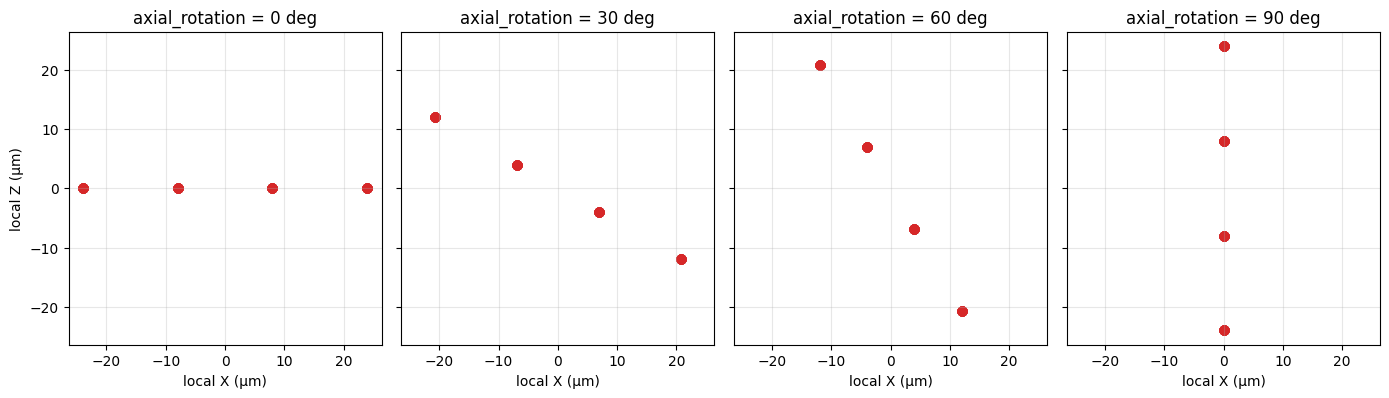

In [7]:
roll_angles = [0.0, 30.0, 60.0, 90.0]
fig, axes = plt.subplots(1, len(roll_angles), figsize=(14, 4), sharex=True, sharey=True)
for ax, angle in zip(axes, roll_angles, strict=True):
    rolled_xyz = np.asarray(
        obi.Neuropixels1ExtracellularLocations(
            n_electrodes=96, axial_rotation=angle
        ).get_local_electrode_xyz_locations(),
        dtype=float,
    )
    ax.scatter(rolled_xyz[:, 0], rolled_xyz[:, 2], s=40, c="tab:red", alpha=0.6)
    ax.set_title(f"axial_rotation = {angle:g} deg")
    ax.set_xlabel("local X (μm)")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("local Z (μm)")
fig.tight_layout()
plt.show()

## Combined figure

`plot_extracellular_arrays(circuit, electrode_locations)` takes a `Circuit` and a dictionary of extracellular-locations blocks and draws the three axis-plane projections, a 3D view, and one local-frame panel per array.

/var/folders/pp/r2gyck8j4n9dfb_x9vjslq740000gn/T/ipykernel_78111/439961687.py:143: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


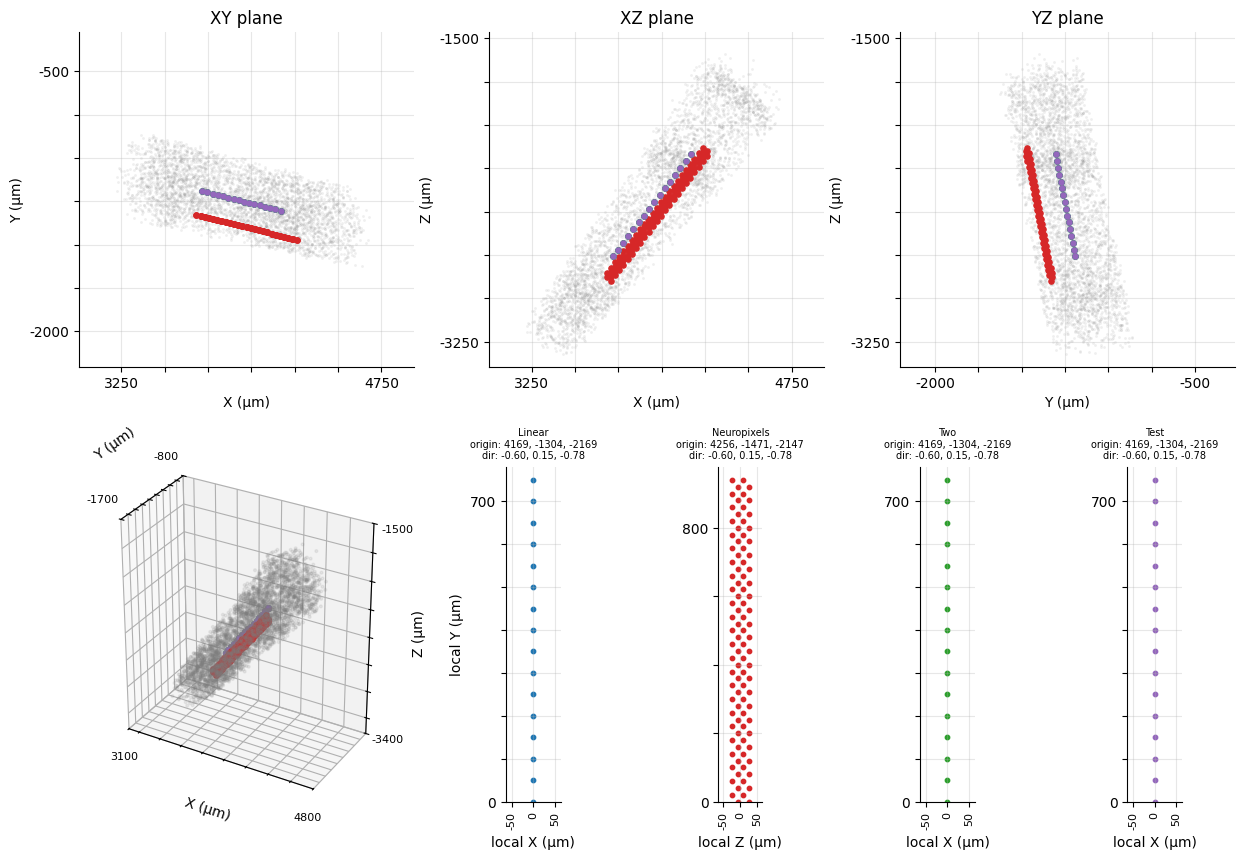

In [11]:
def plot_extracellular_arrays(circuit, electrode_locations):
    """Plot a dictionary of extracellular-electrode arrays relative to a circuit's somas.

    Args:
        circuit: a bluepysnap ``Circuit``; the somas of its (first) biophysical population are shown.
        electrode_locations: dict of ``{name: extracellular-locations block}`` with origin/direction
            already applied. Each entry contributes its global electrode positions (3D + the three
            axis-plane projections) and a local-frame layout panel.

    Returns:
        The matplotlib ``Figure``.
    """
    palette = ["tab:blue", "tab:red", "tab:green", "tab:purple", "tab:orange", "tab:brown"]
    axis_labels = ["X", "Y", "Z"]

    # Somas of the (non-virtual) biophysical population.
    biophysical_pops = [
        name for name in circuit.nodes.population_names if circuit.nodes[name].type != "virtual"
    ]
    soma_xyz = circuit.nodes[biophysical_pops[0]].get(properties=["x", "y", "z"]).to_numpy()

    # Global coordinates and a colour for each array.
    arrays = [
        {"name": name, "block": block, "color": palette[k % len(palette)],
         "xyz": np.asarray(block.get_global_electrode_xyz_locations(), dtype=float)}
        for k, (name, block) in enumerate(electrode_locations.items())
    ]
    electrode_xyz = np.vstack([a["xyz"] for a in arrays])

    # Subsampled/faint soma cloud so the electrodes stay visible for large circuits.
    max_somas = 4000
    rng = np.random.default_rng(0)
    soma_sample = soma_xyz
    if len(soma_xyz) > max_somas:
        soma_sample = soma_xyz[rng.choice(len(soma_xyz), max_somas, replace=False)]
    soma_size, soma_alpha = soma_marker_style(len(soma_xyz))

    def set_extreme_ticks(ax, dims="xy", edges=False):
        """Label only the extreme ticks (and 0, in range); keep the regular gridline marks.

        ``edges=True`` adds the axis limits themselves as labelled ticks, so the extreme labels sit
        at the plot edges even when the auto-ticker is coarse (the small 3D panel); otherwise the
        outermost auto gridlines are labelled. Ticks come from the locator's ``tick_values`` so the
        result is draw-order independent (3D ticks are otherwise only finalised at draw time).
        """
        for d in dims:
            axis = getattr(ax, f"{d}axis")
            lo, hi = getattr(ax, f"get_{d}lim")()
            grid = [
                t
                for t in axis.get_major_locator().tick_values(lo, hi)
                if lo - 1e-9 <= t <= hi + 1e-9
            ]
            if not grid:
                continue
            if edges:
                ticks = sorted({lo, hi, *grid} | ({0.0} if lo < 0 < hi else set()))
                keep = {lo, hi} | {t for t in ticks if abs(t) < 1e-6}
            else:
                ticks = list(grid)
                keep = {grid[0], grid[-1]} | {t for t in grid if abs(t) < 1e-6}
            getattr(ax, f"set_{d}ticks")(ticks)
            getattr(ax, f"set_{d}ticklabels")([f"{t:.0f}" if t in keep else "" for t in ticks])

    n_arrays = len(arrays)
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(2, 3)
    gs_bottom = gs[1, :].subgridspec(1, 1 + n_arrays, width_ratios=[2] + [1] * n_arrays)

    # Top row: the three axis-plane projections (whole circuit; shared square window).
    data_lo = np.minimum(soma_xyz.min(axis=0), electrode_xyz.min(axis=0))
    data_hi = np.maximum(soma_xyz.max(axis=0), electrode_xyz.max(axis=0))
    proj_centre = 0.5 * (data_lo + data_hi)
    proj_half = 0.5 * (data_hi - data_lo).max() * 1.05
    for (i, j), cell in {(0, 1): gs[0, 0], (0, 2): gs[0, 1], (1, 2): gs[0, 2]}.items():
        ax = fig.add_subplot(cell)
        ax.scatter(soma_sample[:, i], soma_sample[:, j], s=soma_size, c="tab:gray", alpha=soma_alpha, linewidths=0)
        for a in arrays:
            ax.scatter(a["xyz"][:, i], a["xyz"][:, j], s=14, c=a["color"], zorder=3)
        ax.set_xlim(proj_centre[i] - proj_half, proj_centre[i] + proj_half)
        ax.set_ylim(proj_centre[j] - proj_half, proj_centre[j] + proj_half)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)
        set_extreme_ticks(ax, "xy")
        ax.set_xlabel(f"{axis_labels[i]} (μm)")
        ax.set_ylabel(f"{axis_labels[j]} (μm)")
        ax.set_title(f"{axis_labels[i]}{axis_labels[j]} plane")

    # Bottom row, left: 3D view (wider, left-aligned).
    ax3d = fig.add_subplot(gs_bottom[0, 0], projection="3d")
    ax3d.scatter(*soma_sample.T, s=soma_size, c="tab:gray", alpha=soma_alpha)
    for a in arrays:
        ax3d.scatter(*a["xyz"].T, s=16, c=a["color"], depthshade=False)
    shown_xyz = np.vstack([soma_sample, electrode_xyz])
    span = np.ptp(shown_xyz, axis=0)
    lo = np.floor((shown_xyz.min(axis=0) - 0.03 * span) / 100.0) * 100.0
    hi = np.ceil((shown_xyz.max(axis=0) + 0.03 * span) / 100.0) * 100.0
    ax3d.set_xlim(lo[0], hi[0])
    ax3d.set_ylim(lo[1], hi[1])
    ax3d.set_zlim(lo[2], hi[2])
    ax3d.set_box_aspect(hi - lo)
    ax3d.set_anchor("W")
    ax3d.view_init(elev=30, azim=-60)
    # Draw the Y axis on the top-left cube edge (matplotlib-internal axis placement).
    ax3d.yaxis._axinfo["juggled"] = (2, 1, 0)
    ax3d.set_xlabel("X (μm)")
    ax3d.set_ylabel("Y (μm)")
    ax3d.zaxis.set_rotate_label(False)
    ax3d.set_zlabel("Z (μm)", rotation=90)
    ax3d.tick_params(labelsize=8)
    set_extreme_ticks(ax3d, "xyz", edges=True)

    # Bottom row, right: each array in its local frame (equal scale, shared width).
    locals_ = []
    for a in arrays:
        local = np.asarray(a["block"].get_local_electrode_xyz_locations(), dtype=float)
        width_axis = 0 if np.ptp(local[:, 0]) >= np.ptp(local[:, 2]) else 2
        locals_.append((local[:, width_axis], local[:, 1], width_axis, a))
    local_x_half = 0.5 * max(np.ptp(x) for x, _, _, _ in locals_) + 40.0
    for col, (x, y, w, a) in enumerate(locals_, start=1):
        ax = fig.add_subplot(gs_bottom[0, col])
        ax.scatter(x, y, s=10, c=a["color"])
        x_centre = 0.5 * (x.min() + x.max())
        ax.set_xlim(x_centre - local_x_half, x_centre + local_x_half)
        ax.set_ylim(y.min(), y.max() + 0.04 * (y.max() - y.min()))
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)
        set_extreme_ticks(ax, "xy")
        ax.tick_params(axis="x", labelrotation=90, labelsize=8)
        ax.set_xlabel(f"local {axis_labels[w]} (μm)")
        if col == 1:
            ax.set_ylabel("local Y (μm)")
        b = a["block"]
        ax.set_title(
            a["name"]
            + chr(10) + f"origin: {b.origin_x:.0f}, {b.origin_y:.0f}, {b.origin_z:.0f}"
            + chr(10) + f"dir: {b.direction_x:.2f}, {b.direction_y:.2f}, {b.direction_z:.2f}",
            fontsize=7,
        )

    fig.tight_layout()
    fig.subplots_adjust(hspace=0.3)
    return fig


electrode_locations = {"Linear": linear_probe, 
                       "Neuropixels": neuropixels_probe, 
                       "Two": linear_probe, 
                    #    "TE": neuropixels_probe, 
                       "Test": linear_probe}
plot_extracellular_arrays(circuit, electrode_locations)
plt.show()

## Test endpoint. Service must be launched first (`make run-local`)

Calls the declared `/declared/extracellular-locations/global-coordinates` endpoint with a JSON
request body for an `ExtracellularLocationsUnion` member (a Neuropixels 1.0 array here), returning
the electrode positions in global coordinates.

In [9]:
from entitysdk import Client, ProjectContext

from obi_auth import get_token

token = get_token(environment="staging")
project_context = ProjectContext(virtual_lab_id=obi.LAB_ID_STAGING_TEST, project_id=obi.PROJECT_ID_STAGING_TEST)
db_client = Client(api_url="https://staging.openbraininstitute.org/api/entitycore", project_context=project_context, token_manager=token)


In [10]:
import requests

# The service must be running (`make run-local`). Provide a valid bearer token, e.g. via
# `from obi_auth import get_token; token = get_token(environment="staging")`.
obi_one_api_url = "http://127.0.0.1:8100"
virtual_lab_id = obi.LAB_ID_STAGING_TEST
project_id = obi.PROJECT_ID_STAGING_TEST

url = f"{obi_one_api_url}/declared/extracellular-locations/global-coordinates"
headers = {
    "Authorization": f"Bearer {token}",
    "Accept": "application/json",
    "Content-Type": "application/json",
}
if virtual_lab_id:
    headers["virtual-lab-id"] = virtual_lab_id
if project_id:
    headers["project-id"] = project_id

# JSON request body: a Neuropixels 1.0 array (an ExtracellularLocationsUnion member).
request_body = {
    "type": "Neuropixels1ExtracellularLocations",
    "origin_x": 3695.0,
    "origin_y": -1089.0,
    "origin_z": -2797.0,
    "direction_x": 0.0,
    "direction_y": 1.0,
    "direction_z": 0.0,
    "n_electrodes": 96,
    "axial_rotation": 30.0,
}

response = requests.post(url, headers=headers, json=request_body)
if response.status_code == 200:
    coordinates = response.json()
    print(f"Success: {len(coordinates)} electrode coordinates")
    print("first electrode (μm):", coordinates[0])
else:
    print(f"Error {response.status_code}: {response.text}")

ConnectionError: HTTPConnectionPool(host='127.0.0.1', port=8100): Max retries exceeded with url: /declared/extracellular-locations/global-coordinates (Caused by NewConnectionError("HTTPConnection(host='127.0.0.1', port=8100): Failed to establish a new connection: [Errno 61] Connection refused"))